# Random Forest Models for Rocket Launch Failure Risk

This notebook builds four random forest classifiers using
`launch_modeling_base_with_weather.csv`:

1. a **base launch-only model**
2. a **base launch + weather model**
3. a **tuned launch-only model**
4. a **tuned launch + weather model**

The target is `is_failure_or_partial`, where `1` means a failed or partially failed launch
and `0` means a successful launch. Because failure is the minority class, the notebook
emphasizes metrics that are more informative than raw accuracy alone, especially:

- balanced accuracy
- recall for the failure class
- ROC AUC

The workflow intentionally respects the provided `data_split` column:

- `train` is used to fit the base models
- `validation` is used to compare base and tuned development models
- `test` is held back for the final out-of-sample comparison after model design choices are made

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import PredefinedSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder

ROOT = Path.cwd()
if not (ROOT / "launch_modeling_base_with_weather.csv").exists() and (
    ROOT.parent / "launch_modeling_base_with_weather.csv"
).exists():
    ROOT = ROOT.parent
DATA_PATH = ROOT / "launch_modeling_base_with_weather.csv"

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)

RANDOM_STATE = 42
TARGET_COL = "is_failure_or_partial"

## Load the Modeling Table

The first check confirms that the file loads correctly, shows the overall shape, and
verifies that the target and split columns are present. This is also a good place to catch
upstream schema changes before any modeling code runs.

In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
print("\nSplit counts:")
print(df["data_split"].value_counts().sort_index())
print("\nTarget distribution:")
print(df[TARGET_COL].value_counts(normalize=True).rename("share").round(4))

df.head()

Dataset shape: 6,168 rows x 88 columns

Split counts:
data_split
test           926
train         4317
validation     925
Name: count, dtype: int64

Target distribution:
is_failure_or_partial
0    0.9121
1    0.0879
Name: share, dtype: float64


,Launch Id,launch_time_utc,launch_date,launch_year,launch_month,launch_month_name,launch_quarter,launch_dayofweek,launch_hour_utc,launch_decade,Launch Status,is_success,is_failure_or_partial,Launch Suborbital,is_suborbital,Rocket Name,Rocket Organisation,company_country,company_ownership,Rocket Price,Rocket Price CPI Adjusted,Rocket Payload to LEO,USD/kg to LEO,USD/kg to LEO CPI Adjusted,Location,Country,Country_Code,Operator,Launch Site,Comb Launch Site,facility_group,Lat,Lon,Launch Site Lat,Launch Site Lon,Comb Launch Site Lat,Comb Launch Site Lon,facility_lat,facility_lon,facility_coordinate_source,payload_count,mission_mass,mission_rows,config_status,config_price_musd_text_parsed,config_liftoff_thrust,config_payload_leo,config_payload_gto,config_stages,config_strap_ons,config_rocket_height,config_fairing_diameter,config_fairing_height,rocket_family,family_success_rate_pct,location_joined,mission_joined,config_joined,company_joined,launch_time_lstd,weather_obs_time_lstd,weather_matched,weather_time_diff_minutes,weather_file_name,weather_station_id,DATE,REPORT_TYPE,HourlyDryBulbTemperature,HourlyDewPointTemperature,HourlySeaLevelPressure,HourlyWindSpeed,HourlyWindDirection,hourly_nonnulls,present_weather_rain_flag,present_weather_fog_flag,present_weather_thunder_flag,cloud_cover_broken_or_overcast_flag,short_duration_precip_max,HourlyStationPressure,HourlyRelativeHumidity,HourlyAltimeterSetting,HourlyPrecipitation,HourlyVisibility,HourlyWindGustSpeed,HourlyWetBulbTemperature,HourlyPresentWeatherType,HourlySkyConditions,data_split
0,590,1957-10-04 19:28:00+00:00,1957-10-04,1957,10,October,4,4,19,1950,Success,1,0,Orbital,0,Sputnik 8K71PS,RVSN USSR,Russia,State,NaN,NaN,510.0,NaN,NaN,"Site 1/5, Baikonur Cosmodrome, Kazakhstan",Kazakhstan,KZ,Russian Aerospace Forces,Baikonur Cosmodrome,Baikonur Cosmodrome,Baikonur Cosmodrome,45.964585,63.305243,45.964585,63.305243,45.964585,63.305243,45.964585,63.305243,Locations.csv Comb Launch Site Lat/Lon,1.0,84.0,1.0,Retired,NaN,4.0,510.0,0.0,2.0,4.0,30.2,2.95,4.0,Sputnik 8K71PS,100.0,True,True,True,True,1957-10-05 00:28:00,NaN,False,NaN,Baikonur_Cosmodrome.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train
1,593,1957-11-03 02:30:00+00:00,1957-11-03,1957,11,November,4,6,2,1950,Success,1,0,Orbital,0,Sputnik 8K71PS,RVSN USSR,Russia,State,NaN,NaN,510.0,NaN,NaN,"Site 1/5, Baikonur Cosmodrome, Kazakhstan",Kazakhstan,KZ,Russian Aerospace Forces,Baikonur Cosmodrome,Baikonur Cosmodrome,Baikonur Cosmodrome,45.964585,63.305243,45.964585,63.305243,45.964585,63.305243,45.964585,63.305243,Locations.csv Comb Launch Site Lat/Lon,1.0,508.0,1.0,Retired,NaN,4.0,510.0,0.0,2.0,4.0,30.2,2.95,4.0,Sputnik 8K71PS,100.0,True,True,True,True,1957-11-03 07:30:00,NaN,False,NaN,Baikonur_Cosmodrome.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train
2,845,1957-12-06 16:44:00+00:00,1957-12-06,1957,12,December,4,4,16,1950,Failure,0,1,Orbital,0,Vanguard,US Navy,USA,State,NaN,NaN,10.0,NaN,NaN,"LC-18A, Cape Canaveral SFS, Florida, USA",United States,US,United States Space Force,Cape Canaveral SFS,Cape Canaveral SFS/Kennedy SC,Cape Canaveral Space Force Station,28.448986,-80.561827,28.489690,-80.563003,28.501081,-80.567792,28.448986,-80.561827,Locations.csv raw Lat/Lon,1.0,2.0,1.0,Retired,NaN,135.0,10.0,NaN,3.0,0.0,23.0,NaN,NaN,Vanguard,22.7,True,True,True,True,1957-12-06 11:44:00,1957-12-06 12:00:00,True,16.0,cape_canaveral_sfs.csv,USW00012868,1957-12-06T12:00:00,SAO,70.0,53.0,30.37,16.0,110.0,11.0,False,False,False,False,NaN,30.35,55.0,NaN,NaN,9.94,NaN,60.0,||00,SCT:03 44,train
3,844,1958-02-01 03:47:00+00:00,1958-02-01,1958,2,February,1,5,3,1950,Success,1,0,Orbital,0,Juno I,ABMA,USA,State,NaN,NaN,11.0,NaN,NaN,"LC-26A, Cape Canaveral SFS, Florida, USA",United States,US,United States Space Force,Cape Canaveral SFS,Cape Canaveral SFS/Kennedy SC,Cape Canaveral Space Force Station,28.439421,-80.573307,28.489690,-80.563003,28.501081

## Define the Feature Sets

To keep the modeling inputs easy to audit, this notebook uses explicit include lists rather
than exclusion rules.

We build two related feature sets:

- **launch-only features**: everything that is launch-, rocket-, organization-, and location-specific
- **launch + weather features**: the same launch-only fields plus the matched weather fields

The included columns are limited to fields that are plausibly available at or before
launch time and that represent launch context rather than data-joining artifacts. That
means the feature lists intentionally leave out identifiers, target columns, aggregate
success-rate features, post-hoc status fields, and weather match provenance columns.

In [3]:
launch_only_features = [
    "launch_year",
    "launch_month",
    "launch_month_name",
    "launch_quarter",
    "launch_dayofweek",
    "launch_hour_utc",
    "launch_decade",
    "Launch Suborbital",
    "is_suborbital",
    "Rocket Name",
    "Rocket Organisation",
    "company_country",
    "company_ownership",
    "Rocket Price",
    "Rocket Price CPI Adjusted",
    "Rocket Payload to LEO",
    "USD/kg to LEO",
    "USD/kg to LEO CPI Adjusted",
    "Location",
    "Country",
    "Country_Code",
    "Operator",
    "Launch Site",
    "Comb Launch Site",
    "facility_group",
    "Lat",
    "Lon",
    "Launch Site Lat",
    "Launch Site Lon",
    "Comb Launch Site Lat",
    "Comb Launch Site Lon",
    "facility_lat",
    "facility_lon",
    "payload_count",
    "mission_mass",
    "mission_rows",
    "config_price_musd_text_parsed",
    "config_liftoff_thrust",
    "config_payload_leo",
    "config_payload_gto",
    "config_stages",
    "config_strap_ons",
    "config_rocket_height",
    "config_fairing_diameter",
    "config_fairing_height",
    "rocket_family",
]

weather_feature_cols = [
    "HourlyDryBulbTemperature",
    "HourlyDewPointTemperature",
    "HourlySeaLevelPressure",
    "HourlyWindSpeed",
    "HourlyWindDirection",
    "present_weather_rain_flag",
    "present_weather_fog_flag",
    "present_weather_thunder_flag",
    "cloud_cover_broken_or_overcast_flag",
    "short_duration_precip_max",
    "HourlyStationPressure",
    "HourlyRelativeHumidity",
    "HourlyAltimeterSetting",
    "HourlyPrecipitation",
    "HourlyVisibility",
    "HourlyWindGustSpeed",
    "HourlyWetBulbTemperature",
    "HourlyPresentWeatherType",
    "HourlySkyConditions",
]

missing_launch_features = [col for col in launch_only_features if col not in df.columns]
missing_weather_features = [col for col in weather_feature_cols if col not in df.columns]

if missing_launch_features or missing_weather_features:
    raise ValueError(
        "One or more expected modeling columns are missing. "
        f"Launch-only missing: {missing_launch_features}. "
        f"Weather missing: {missing_weather_features}."
    )

weather_features = launch_only_features + weather_feature_cols

feature_summary = pd.DataFrame(
    {
        "feature_set": ["launch_only", "launch_plus_weather"],
        "num_features": [len(launch_only_features), len(weather_features)],
    }
)

feature_summary

,feature_set,num_features
0,launch_only,46
1,launch_plus_weather,65


## Inspect the Modeling Splits and Class Balance

These charts establish two important facts before training anything:

- the supplied `data_split` partitions are the backbone of the workflow
- the target is highly imbalanced, so a model can achieve high accuracy while still doing a
  poor job identifying failures

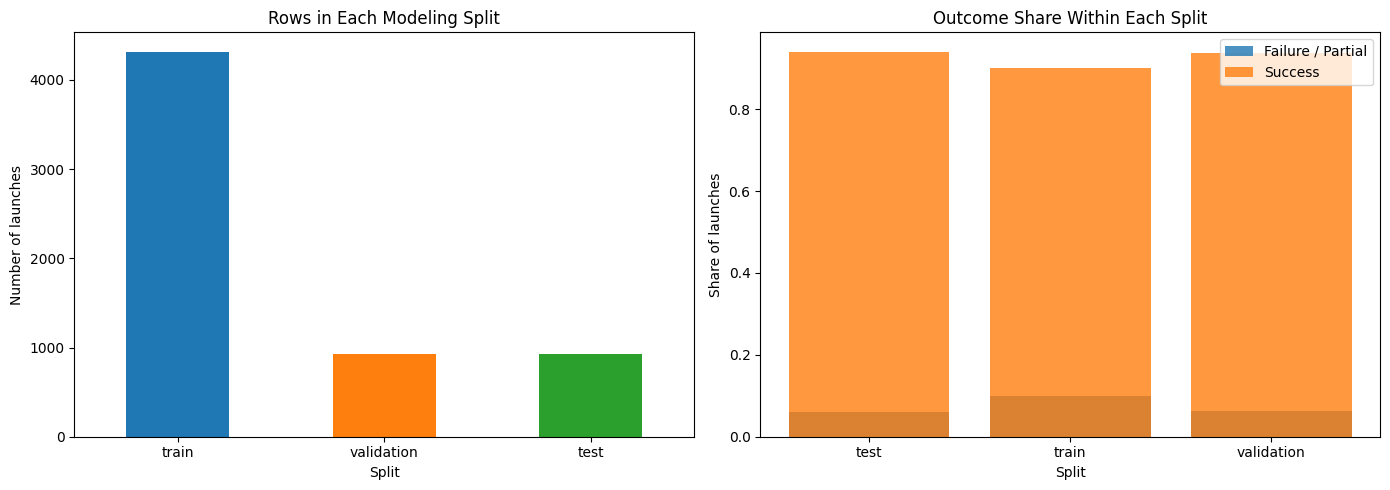

In [4]:
split_counts = (
    df["data_split"]
    .value_counts()
    .reindex(["train", "validation", "test"])
)

target_by_split = (
    df.groupby("data_split")[TARGET_COL]
    .value_counts(normalize=True)
    .rename("share")
    .reset_index()
)
target_by_split["launch_outcome"] = target_by_split[TARGET_COL].map({1: "Failure / Partial", 0: "Success"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

split_counts.plot(kind="bar", ax=axes[0], color=["#1f77b4", "#ff7f0e", "#2ca02c"])
axes[0].set_title("Rows in Each Modeling Split")
axes[0].set_xlabel("Split")
axes[0].set_ylabel("Number of launches")
axes[0].tick_params(axis="x", rotation=0)

for split_name, group in target_by_split.groupby("launch_outcome"):
    axes[1].bar(
        group["data_split"],
        group["share"],
        label=split_name,
        alpha=0.8,
    )
axes[1].set_title("Outcome Share Within Each Split")
axes[1].set_xlabel("Split")
axes[1].set_ylabel("Share of launches")
axes[1].legend()

plt.tight_layout()
plt.show()

## Inspect Weather Coverage and Missingness

The weather-augmented model can only help if the matched weather data carries signal.
This section measures how often weather was actually matched and highlights the weather
variables with the most missing values. That context matters when later interpreting why
weather adds only a small or moderate lift.

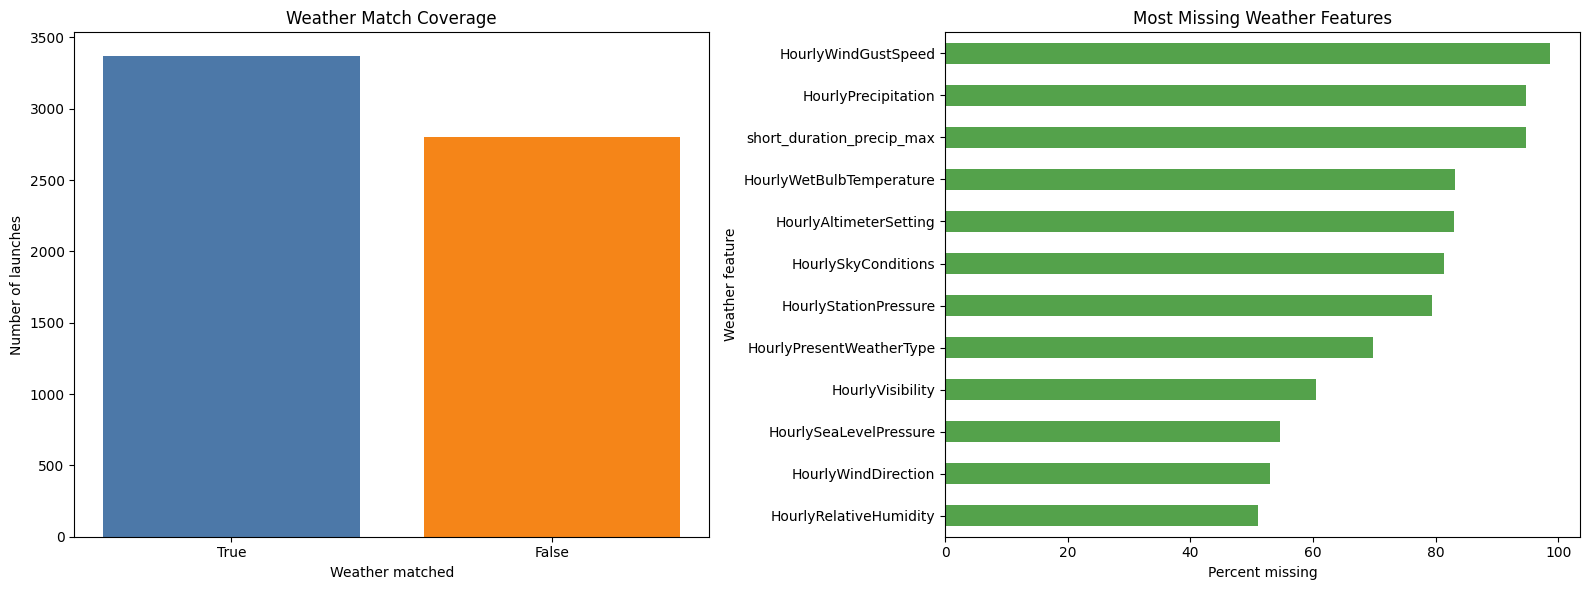

,missing_pct
HourlyWindGustSpeed,98.605707
short_duration_precip_max,94.763294
HourlyPrecipitation,94.763294
HourlyWetBulbTemperature,83.187419
HourlyAltimeterSetting,82.960441
HourlySkyConditions,81.290532
HourlyStationPressure,79.458495
HourlyPresentWeatherType,69.763294
HourlyVisibility,60.538262
HourlySeaLevelPressure,54.653048


In [5]:
weather_coverage = (
    df["weather_matched"]
    .value_counts(dropna=False)
    .rename_axis("weather_matched")
    .reset_index(name="rows")
)
weather_coverage["share"] = weather_coverage["rows"] / len(df)

weather_missing = (
    df[[col for col in weather_feature_cols if col in df.columns]]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .mul(100)
    .rename("missing_pct")
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(
    weather_coverage["weather_matched"].astype(str),
    weather_coverage["rows"],
    color=["#4c78a8", "#f58518"],
)
axes[0].set_title("Weather Match Coverage")
axes[0].set_xlabel("Weather matched")
axes[0].set_ylabel("Number of launches")

weather_missing.head(12).sort_values().plot(kind="barh", ax=axes[1], color="#54a24b")
axes[1].set_title("Most Missing Weather Features")
axes[1].set_xlabel("Percent missing")
axes[1].set_ylabel("Weather feature")

plt.tight_layout()
plt.show()

weather_missing.head(12).to_frame()

## Create Split DataFrames

The project already provides the split assignment. We convert that into explicit train,
validation, and test matrices once so every later modeling step uses the same partitions.

In [6]:
train_mask = df["data_split"].eq("train")
val_mask = df["data_split"].eq("validation")
test_mask = df["data_split"].eq("test")
trainval_mask = df["data_split"].isin(["train", "validation"])

y_train = df.loc[train_mask, TARGET_COL]
y_val = df.loc[val_mask, TARGET_COL]
y_test = df.loc[test_mask, TARGET_COL]
y_trainval = df.loc[trainval_mask, TARGET_COL]

split_data = {
    "launch_only": {
        "X_train": df.loc[train_mask, launch_only_features],
        "X_val": df.loc[val_mask, launch_only_features],
        "X_test": df.loc[test_mask, launch_only_features],
        "X_trainval": df.loc[trainval_mask, launch_only_features],
    },
    "launch_plus_weather": {
        "X_train": df.loc[train_mask, weather_features],
        "X_val": df.loc[val_mask, weather_features],
        "X_test": df.loc[test_mask, weather_features],
        "X_trainval": df.loc[trainval_mask, weather_features],
    },
}

{
    name: {split_name: split_df.shape for split_name, split_df in parts.items()}
    for name, parts in split_data.items()
}

{'launch_only': {'X_train': (4317, 46),
  'X_val': (925, 46),
  'X_test': (926, 46),
  'X_trainval': (5242, 46)},
 'launch_plus_weather': {'X_train': (4317, 65),
  'X_val': (925, 65),
  'X_test': (926, 65),
  'X_trainval': (5242, 65)}}

## Modeling Helpers

The helper functions below keep the modeling code readable and consistent:

- `build_pipeline` handles missing values and one-hot encoding before fitting the forest
- `collect_metrics` reports a balanced set of evaluation metrics
- `plot_confusion_matrices` and `plot_roc_curves` create side-by-side visual comparisons
- `run_random_search` tunes hyperparameters while respecting the predefined train and
  validation split

One important preprocessing detail: several weather flags mix boolean and text values, so
the categorical pipeline explicitly converts categories to strings before one-hot encoding.

In [7]:
def build_pipeline(X: pd.DataFrame, rf_params: dict | None = None) -> Pipeline:
    rf_params = rf_params or {}

    numeric_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_cols = [col for col in X.columns if col not in numeric_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                    ]
                ),
                numeric_cols,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
                        (
                            "to_string",
                            FunctionTransformer(
                                lambda data: data.astype(str),
                                feature_names_out="one-to-one",
                            ),
                        ),
                        (
                            "onehot",
                            OneHotEncoder(
                                handle_unknown="ignore",
                                sparse_output=False,
                            ),
                        ),
                    ]
                ),
                categorical_cols,
            ),
        ]
    )

    model_defaults = {
        "n_estimators": 400,
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "class_weight": "balanced_subsample",
    }
    model_defaults.update(rf_params)

    model = RandomForestClassifier(**model_defaults)

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )


def collect_metrics(model: Pipeline, X: pd.DataFrame, y_true: pd.Series, split_name: str, model_name: str):
    y_pred = model.predict(X)
    y_score = model.predict_proba(X)[:, 1]
    cm = confusion_matrix(y_true, y_pred)

    return {
        "model": model_name,
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "failure_precision": precision_score(y_true, y_pred, zero_division=0),
        "failure_recall": recall_score(y_true, y_pred, zero_division=0),
        "success_recall": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "tn": cm[0, 0],
        "fp": cm[0, 1],
        "fn": cm[1, 0],
        "tp": cm[1, 1],
    }


def metrics_frame(metric_rows: list[dict]) -> pd.DataFrame:
    metric_cols = [
        "accuracy",
        "balanced_accuracy",
        "failure_recall",
        "failure_precision",
        "success_recall",
        "f1",
        "roc_auc",
    ]
    out = pd.DataFrame(metric_rows)
    out[metric_cols] = out[metric_cols].round(4)
    return out


def plot_confusion_matrices(model_dict: dict, X: pd.DataFrame, y_true: pd.Series, title_prefix: str):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.ravel()

    for ax, (model_name, model) in zip(axes, model_dict.items()):
        ConfusionMatrixDisplay.from_predictions(
            y_true,
            model.predict(X),
            ax=ax,
            cmap="Blues",
            colorbar=False,
        )
        ax.set_title(f"{title_prefix}: {model_name}")

    plt.tight_layout()
    plt.show()


def plot_roc_curves(model_dict: dict, X: pd.DataFrame, y_true: pd.Series, title: str):
    plt.figure(figsize=(8, 6))
    for model_name, model in model_dict.items():
        y_score = model.predict_proba(X)[:, 1]
        fpr, tpr, _ = roc_curve(y_true, y_score)
        auc = roc_auc_score(y_true, y_score)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def run_random_search(X_train: pd.DataFrame, X_val: pd.DataFrame, y_train: pd.Series, y_val: pd.Series):
    X_dev = pd.concat([X_train, X_val], axis=0)
    y_dev = pd.concat([y_train, y_val], axis=0)
    split_index = np.r_[np.full(len(X_train), -1), np.zeros(len(X_val), dtype=int)]
    predefined_split = PredefinedSplit(test_fold=split_index)

    param_distributions = {
        "model__n_estimators": [200, 400, 600, 800],
        "model__max_depth": [None, 8, 12, 16, 24],
        "model__min_samples_split": [2, 5, 10, 20],
        "model__min_samples_leaf": [1, 2, 4, 8],
        "model__max_features": ["sqrt", "log2", 0.4, 0.6, None],
        "model__max_leaf_nodes": [None, 32, 64, 128, 256],
    }

    search = RandomizedSearchCV(
        estimator=build_pipeline(X_train),
        param_distributions=param_distributions,
        n_iter=20,
        scoring="roc_auc",
        cv=predefined_split,
        random_state=RANDOM_STATE,
        n_jobs=1,
        refit=False,
        verbose=0,
    )
    search.fit(X_dev, y_dev)

    best_params = {key.replace("model__", ""): value for key, value in search.best_params_.items()}

    search_results = (
        pd.DataFrame(search.cv_results_)
        .sort_values("rank_test_score")
        .loc[
            :,
            [
                "rank_test_score",
                "mean_test_score",
                "param_model__n_estimators",
                "param_model__max_depth",
                "param_model__min_samples_split",
                "param_model__min_samples_leaf",
                "param_model__max_features",
                "param_model__max_leaf_nodes",
            ],
        ]
        .rename(columns={"mean_test_score": "validation_roc_auc"})
    )
    search_results["validation_roc_auc"] = search_results["validation_roc_auc"].round(4)

    return best_params, search_results


def fit_model(X_train: pd.DataFrame, y_train: pd.Series, rf_params: dict | None = None):
    model = build_pipeline(X_train, rf_params=rf_params)
    model.fit(X_train, y_train)
    return model


def get_feature_importance_frame(model: Pipeline, top_n: int = 15) -> pd.DataFrame:
    feature_names = model.named_steps["preprocessor"].get_feature_names_out()
    importances = model.named_steps["model"].feature_importances_
    importance_df = pd.DataFrame(
        {
            "feature": feature_names,
            "importance": importances,
        }
    ).sort_values("importance", ascending=False)
    return importance_df.head(top_n)


def interpretation_text(metrics_df: pd.DataFrame, focus_split: str) -> str:
    subset = metrics_df.loc[metrics_df["split"] == focus_split].copy()
    top_auc = subset.sort_values("roc_auc", ascending=False).iloc[0]
    top_balanced = subset.sort_values("balanced_accuracy", ascending=False).iloc[0]

    lines = [
        f"Best ROC AUC on {focus_split}: {top_auc['model']} ({top_auc['roc_auc']:.4f}).\n"
        f"Best balanced accuracy on {focus_split}: {top_balanced['model']} "
        f"({top_balanced['balanced_accuracy']:.4f})."
    ]

    if {"Base Launch-Only", "Base Launch + Weather"}.issubset(set(subset["model"])):
        launch_base_auc = subset.loc[subset["model"] == "Base Launch-Only", "roc_auc"].iloc[0]
        weather_base_auc = subset.loc[subset["model"] == "Base Launch + Weather", "roc_auc"].iloc[0]
        lines.append(f"Weather lift in the base models: {weather_base_auc - launch_base_auc:+.4f} ROC AUC.")

    if {"Tuned Launch-Only", "Tuned Launch + Weather"}.issubset(set(subset["model"])):
        launch_tuned_auc = subset.loc[subset["model"] == "Tuned Launch-Only", "roc_auc"].iloc[0]
        weather_tuned_auc = subset.loc[subset["model"] == "Tuned Launch + Weather", "roc_auc"].iloc[0]
        lines.append(f"Weather lift in the tuned models: {weather_tuned_auc - launch_tuned_auc:+.4f} ROC AUC.")

    return "\n".join(lines)

## Fit the Two Base Models

These are the benchmark models. Both use the same default random forest configuration and
are trained only on the `train` split. The only difference is whether weather features are
included.

In [8]:
base_models = {
    "Base Launch-Only": fit_model(
        split_data["launch_only"]["X_train"],
        y_train,
    ),
    "Base Launch + Weather": fit_model(
        split_data["launch_plus_weather"]["X_train"],
        y_train,
    ),
}

base_models.keys()

dict_keys(['Base Launch-Only', 'Base Launch + Weather'])

## Evaluate the Base Models on the Validation Split

The validation split is the first honest comparison point. This is where we check whether
adding weather improves the untuned model and whether the models are doing any meaningful
minority-class discrimination at all.

In [9]:
base_validation_metrics = metrics_frame(
    [
        collect_metrics(
            base_models["Base Launch-Only"],
            split_data["launch_only"]["X_val"],
            y_val,
            split_name="validation",
            model_name="Base Launch-Only",
        ),
        collect_metrics(
            base_models["Base Launch + Weather"],
            split_data["launch_plus_weather"]["X_val"],
            y_val,
            split_name="validation",
            model_name="Base Launch + Weather",
        ),
    ]
)

base_validation_metrics

,model,split,accuracy,balanced_accuracy,failure_precision,failure_recall,success_recall,f1,roc_auc,tn,fp,fn,tp
0,Base Launch-Only,validation,0.9373,0.5158,0.4000,0.0351,0.9965,0.0645,0.6663,865,3,55,2
1,Base Launch + Weather,validation,0.9373,0.5076,0.3333,0.0175,0.9977,0.0333,0.6613,866,2,56,1


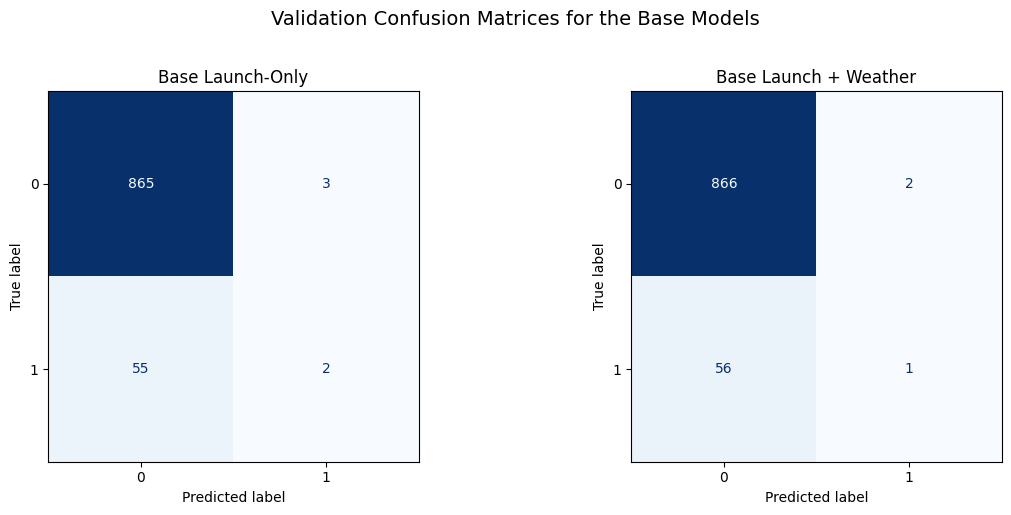

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (model_name, X_val_current) in zip(
    axes,
    [
        ("Base Launch-Only", split_data["launch_only"]["X_val"]),
        ("Base Launch + Weather", split_data["launch_plus_weather"]["X_val"]),
    ],
):
    ConfusionMatrixDisplay.from_predictions(
        y_val,
        base_models[model_name].predict(X_val_current),
        ax=ax,
        cmap="Blues",
        colorbar=False,
    )
    ax.set_title(model_name)

plt.suptitle("Validation Confusion Matrices for the Base Models", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

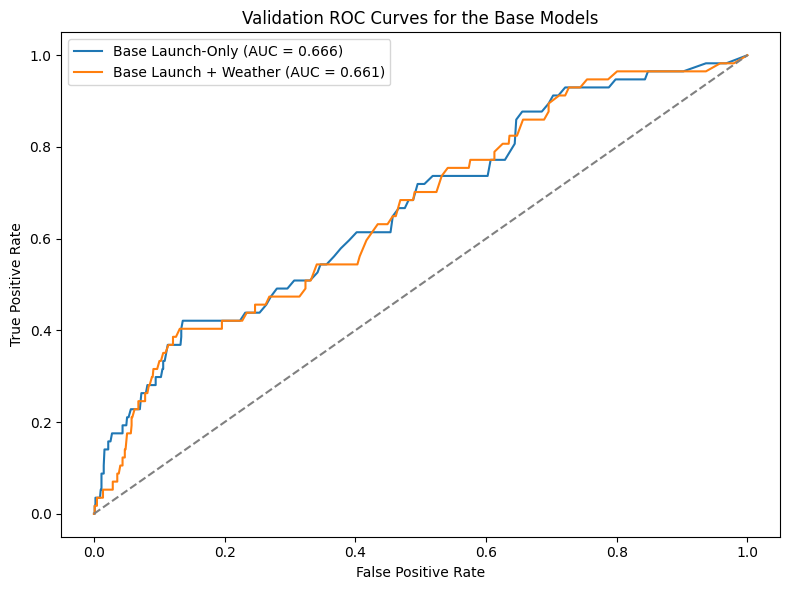

In [11]:
plt.figure(figsize=(8, 6))
for model_name, X_val_current in [
    ("Base Launch-Only", split_data["launch_only"]["X_val"]),
    ("Base Launch + Weather", split_data["launch_plus_weather"]["X_val"]),
]:
    y_score = base_models[model_name].predict_proba(X_val_current)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_score)
    auc = roc_auc_score(y_val, y_score)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curves for the Base Models")
plt.legend()
plt.tight_layout()
plt.show()

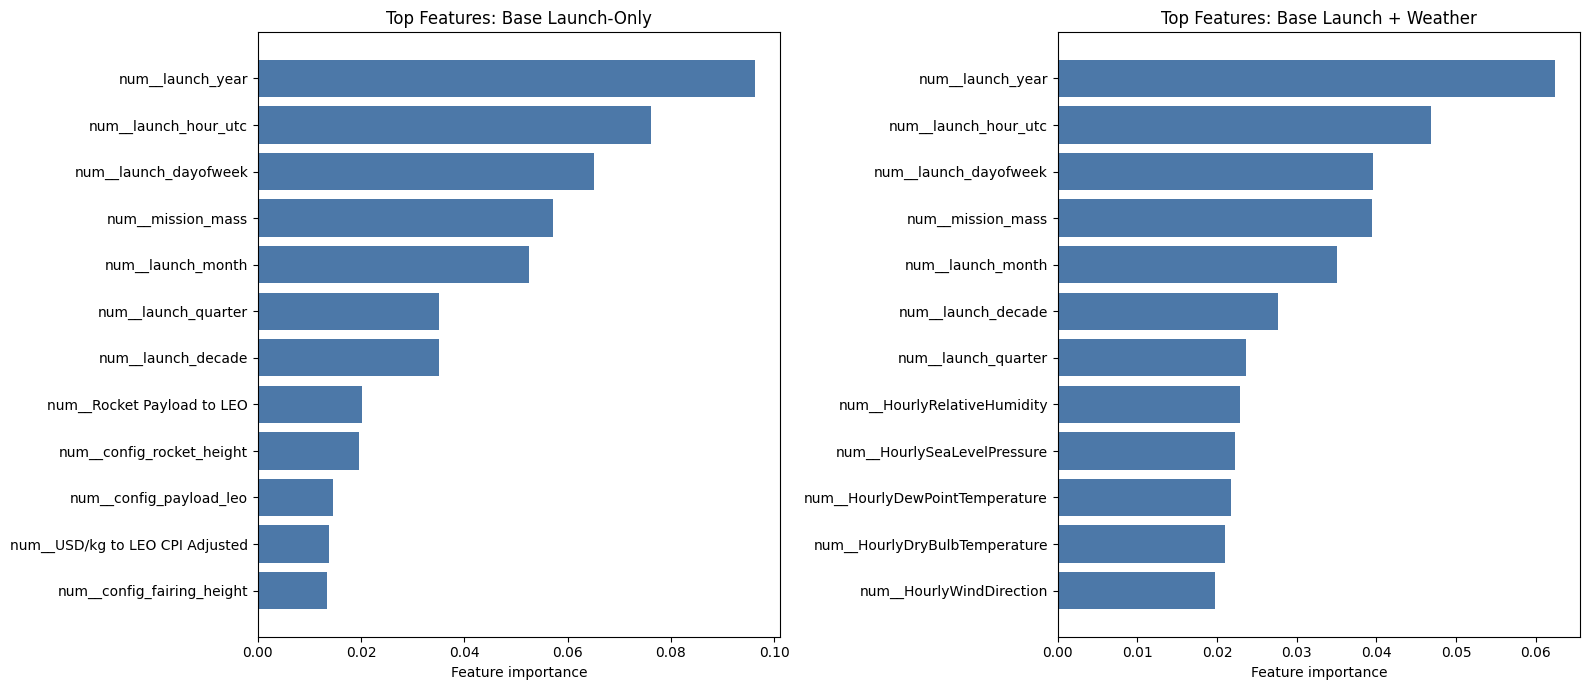

In [12]:
base_feature_importances = {
    model_name: get_feature_importance_frame(model, top_n=12)
    for model_name, model in base_models.items()
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (model_name, importance_df) in zip(axes, base_feature_importances.items()):
    ax.barh(
        importance_df["feature"][::-1],
        importance_df["importance"][::-1],
        color="#4c78a8",
    )
    ax.set_title(f"Top Features: {model_name}")
    ax.set_xlabel("Feature importance")

plt.tight_layout()
plt.show()

In [13]:
print(interpretation_text(base_validation_metrics, focus_split="validation"))

Best ROC AUC on validation: Base Launch-Only (0.6663).
Best balanced accuracy on validation: Base Launch-Only (0.5158).
Weather lift in the base models: -0.0050 ROC AUC.


## Hyperparameter Tuning

Next, we keep the feature sets fixed and tune the forest hyperparameters. The search uses a
`PredefinedSplit` so every candidate is trained on the original `train` rows and scored on
the original `validation` rows. That keeps the tuning process aligned with the supplied
split discipline rather than creating new random folds.

In [14]:
launch_tuned_params, launch_search_results = run_random_search(
    split_data["launch_only"]["X_train"],
    split_data["launch_only"]["X_val"],
    y_train,
    y_val,
)

weather_tuned_params, weather_search_results = run_random_search(
    split_data["launch_plus_weather"]["X_train"],
    split_data["launch_plus_weather"]["X_val"],
    y_train,
    y_val,
)

pd.DataFrame(
    [
        {"model": "Tuned Launch-Only", **launch_tuned_params},
        {"model": "Tuned Launch + Weather", **weather_tuned_params},
    ]
)

,model,n_estimators,min_samples_split,min_samples_leaf,max_leaf_nodes,max_features,max_depth
0,Tuned Launch-Only,600,2,1,64,sqrt,None
1,Tuned Launch + Weather,600,2,1,64,sqrt,None


In [15]:
print("Top launch-only tuning candidates:")
display(launch_search_results.head(5))

print("Top weather-augmented tuning candidates:")
display(weather_search_results.head(5))

Top launch-only tuning candidates:


,rank_test_score,validation_roc_auc,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features,param_model__max_leaf_nodes
19,1,0.6975,600,None,2,1,sqrt,64
15,2,0.6904,200,12,5,8,sqrt,128
13,3,0.6796,600,16,10,1,0.4,64
0,4,0.6793,600,24,5,4,0.4,128
1,5,0.6775,800,24,2,8,0.6,128


Top weather-augmented tuning candidates:


,rank_test_score,validation_roc_auc,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features,param_model__max_leaf_nodes
19,1,0.6936,600,None,2,1,sqrt,64
15,2,0.6805,200,12,5,8,sqrt,128
13,3,0.6781,600,16,10,1,0.4,64
8,4,0.6763,600,16,5,4,0.4,256
0,5,0.6759,600,24,5,4,0.4,128


## Fit the Tuned Development Models

After selecting the best hyperparameters from the train/validation search, we fit new
models on the `train` split only so we can compare their validation-set behavior directly
against the base models.

In [16]:
tuned_dev_models = {
    "Tuned Launch-Only": fit_model(
        split_data["launch_only"]["X_train"],
        y_train,
        rf_params=launch_tuned_params,
    ),
    "Tuned Launch + Weather": fit_model(
        split_data["launch_plus_weather"]["X_train"],
        y_train,
        rf_params=weather_tuned_params,
    ),
}

tuned_dev_models.keys()

dict_keys(['Tuned Launch-Only', 'Tuned Launch + Weather'])

## Compare All Four Development Models on the Validation Split

This is the key development-stage comparison. It shows whether the tuned models are really
better at identifying failure risk than the base models and whether weather features still
provide incremental value after tuning.

In [17]:
all_validation_metrics = metrics_frame(
    [
        collect_metrics(
            base_models["Base Launch-Only"],
            split_data["launch_only"]["X_val"],
            y_val,
            split_name="validation",
            model_name="Base Launch-Only",
        ),
        collect_metrics(
            base_models["Base Launch + Weather"],
            split_data["launch_plus_weather"]["X_val"],
            y_val,
            split_name="validation",
            model_name="Base Launch + Weather",
        ),
        collect_metrics(
            tuned_dev_models["Tuned Launch-Only"],
            split_data["launch_only"]["X_val"],
            y_val,
            split_name="validation",
            model_name="Tuned Launch-Only",
        ),
        collect_metrics(
            tuned_dev_models["Tuned Launch + Weather"],
            split_data["launch_plus_weather"]["X_val"],
            y_val,
            split_name="validation",
            model_name="Tuned Launch + Weather",
        ),
    ]
)

all_validation_metrics.sort_values(["roc_auc", "balanced_accuracy"], ascending=False)

,model,split,accuracy,balanced_accuracy,failure_precision,failure_recall,success_recall,f1,roc_auc,tn,fp,fn,tp
2,Tuned Launch-Only,validation,0.8259,0.6204,0.1486,0.3860,0.8548,0.2146,0.6975,742,126,35,22
3,Tuned Launch + Weather,validation,0.8454,0.6226,0.1641,0.3684,0.8767,0.2270,0.6936,761,107,36,21
0,Base Launch-Only,validation,0.9373,0.5158,0.4000,0.0351,0.9965,0.0645,0.6663,865,3,55,2
1,Base Launch + Weather,validation,0.9373,0.5076,0.3333,0.0175,0.9977,0.0333,0.6613,866,2,56,1


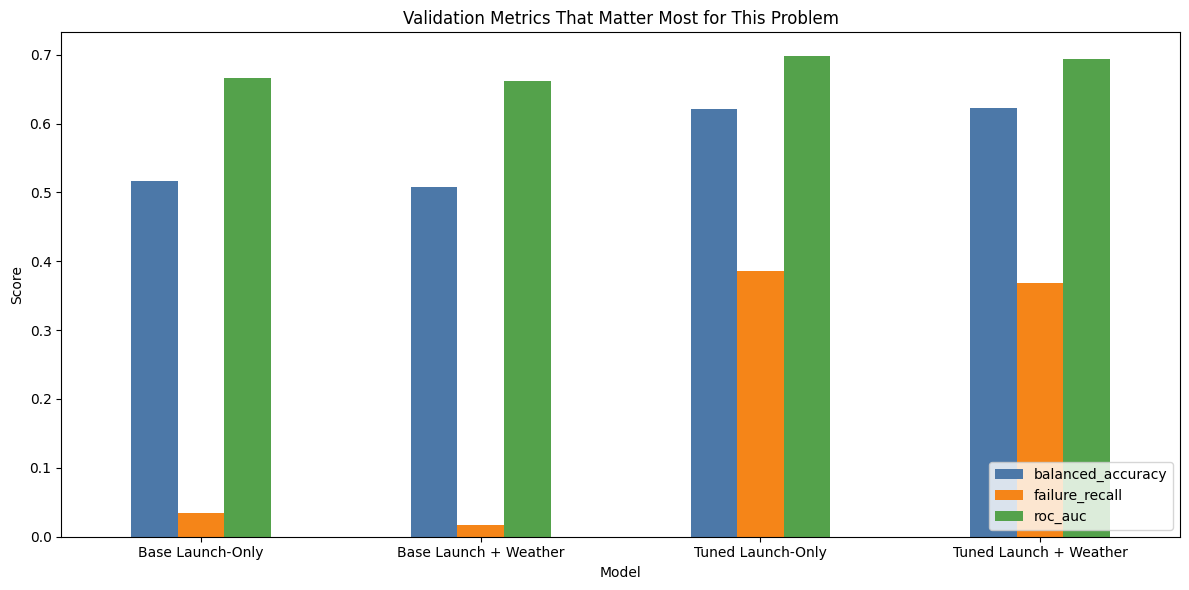

In [18]:
metric_plot_df = all_validation_metrics.set_index("model")[
    ["balanced_accuracy", "failure_recall", "roc_auc"]
]

metric_plot_df.plot(kind="bar", figsize=(12, 6), color=["#4c78a8", "#f58518", "#54a24b"])
plt.title("Validation Metrics That Matter Most for This Problem")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

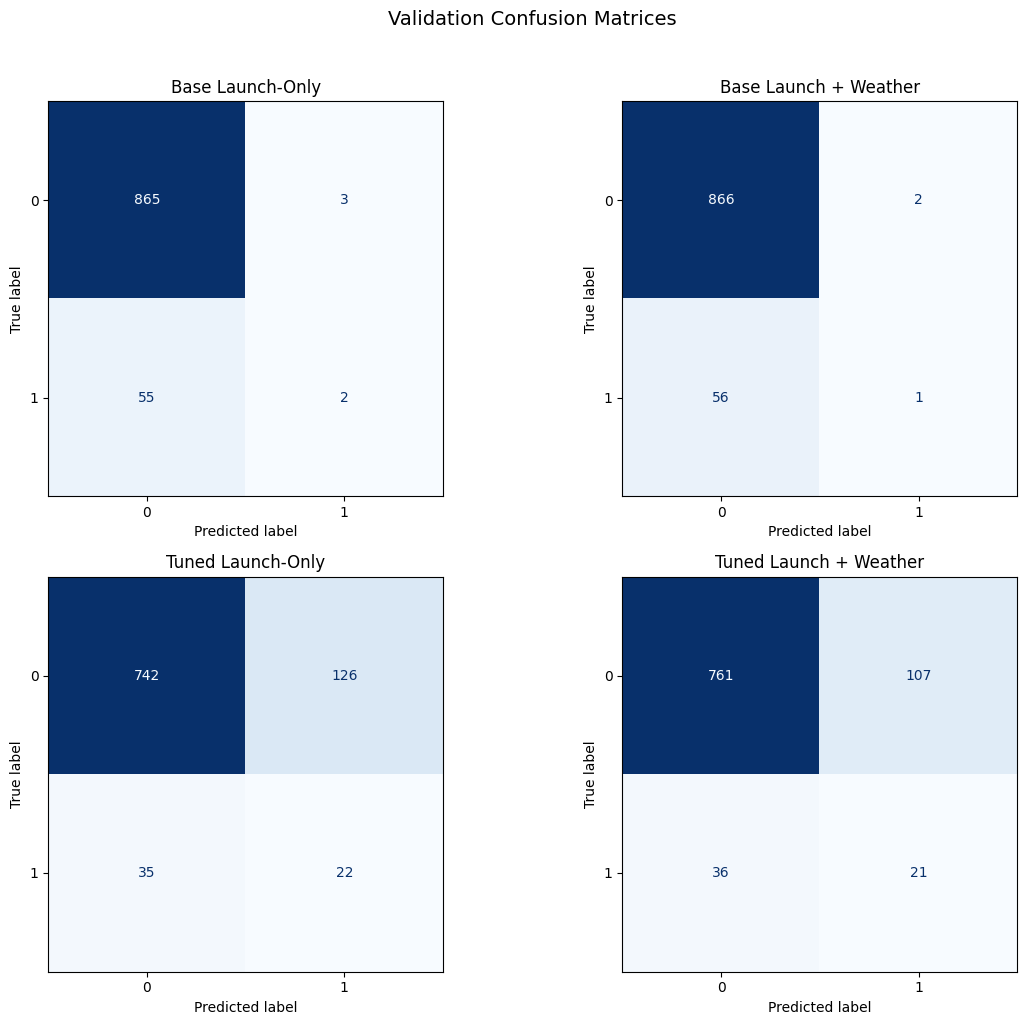

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

validation_plot_inputs = [
    ("Base Launch-Only", base_models["Base Launch-Only"], split_data["launch_only"]["X_val"]),
    ("Base Launch + Weather", base_models["Base Launch + Weather"], split_data["launch_plus_weather"]["X_val"]),
    ("Tuned Launch-Only", tuned_dev_models["Tuned Launch-Only"], split_data["launch_only"]["X_val"]),
    ("Tuned Launch + Weather", tuned_dev_models["Tuned Launch + Weather"], split_data["launch_plus_weather"]["X_val"]),
]

for ax, (model_name, model, X_val_current) in zip(axes, validation_plot_inputs):
    ConfusionMatrixDisplay.from_predictions(
        y_val,
        model.predict(X_val_current),
        ax=ax,
        cmap="Blues",
        colorbar=False,
    )
    ax.set_title(model_name)

plt.suptitle("Validation Confusion Matrices", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

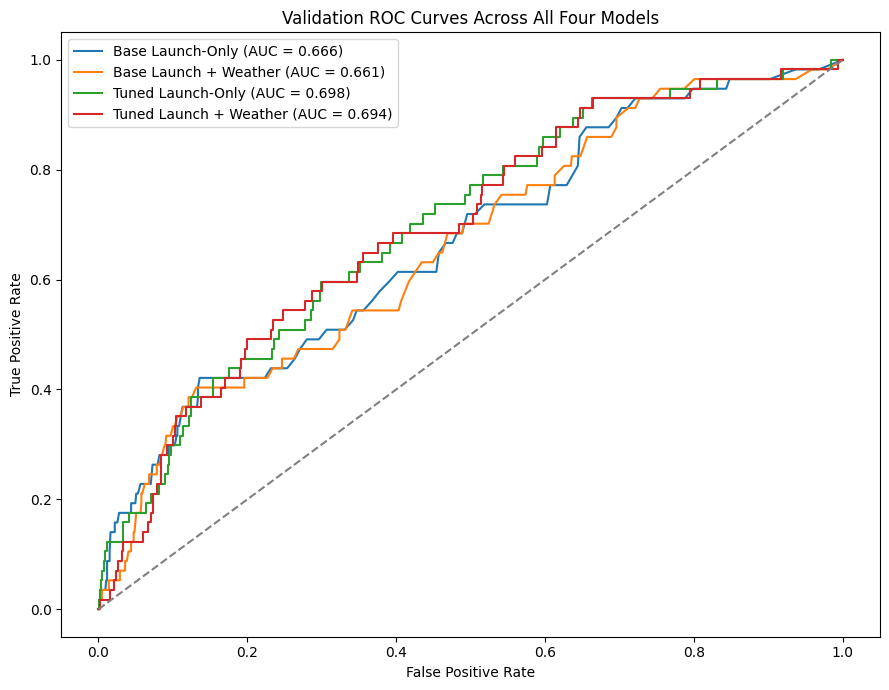

In [20]:
plt.figure(figsize=(9, 7))
for model_name, model, X_val_current in validation_plot_inputs:
    y_score = model.predict_proba(X_val_current)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_score)
    auc = roc_auc_score(y_val, y_score)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curves Across All Four Models")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
print(interpretation_text(all_validation_metrics, focus_split="validation"))

Best ROC AUC on validation: Tuned Launch-Only (0.6975).
Best balanced accuracy on validation: Tuned Launch + Weather (0.6226).
Weather lift in the base models: -0.0050 ROC AUC.
Weather lift in the tuned models: -0.0039 ROC AUC.


## Refit the Selected Model Configurations on Train + Validation

Once the development comparison is complete, the final model configurations can use both
the `train` and `validation` rows for fitting. The `test` split remains untouched until
this point, so the final scores below are the cleanest estimate of out-of-sample
performance.

In [22]:
final_models = {
    "Base Launch-Only": fit_model(
        split_data["launch_only"]["X_trainval"],
        y_trainval,
    ),
    "Base Launch + Weather": fit_model(
        split_data["launch_plus_weather"]["X_trainval"],
        y_trainval,
    ),
    "Tuned Launch-Only": fit_model(
        split_data["launch_only"]["X_trainval"],
        y_trainval,
        rf_params=launch_tuned_params,
    ),
    "Tuned Launch + Weather": fit_model(
        split_data["launch_plus_weather"]["X_trainval"],
        y_trainval,
        rf_params=weather_tuned_params,
    ),
}

final_models.keys()

dict_keys(['Base Launch-Only', 'Base Launch + Weather', 'Tuned Launch-Only', 'Tuned Launch + Weather'])

## Final Holdout Test Evaluation

This is the final comparison that should matter most for the report. The test split has not
been used for feature-set selection or hyperparameter tuning, so these metrics represent the
most defensible model comparison in the notebook.

In [23]:
final_test_metrics = metrics_frame(
    [
        collect_metrics(
            final_models["Base Launch-Only"],
            split_data["launch_only"]["X_test"],
            y_test,
            split_name="test",
            model_name="Base Launch-Only",
        ),
        collect_metrics(
            final_models["Base Launch + Weather"],
            split_data["launch_plus_weather"]["X_test"],
            y_test,
            split_name="test",
            model_name="Base Launch + Weather",
        ),
        collect_metrics(
            final_models["Tuned Launch-Only"],
            split_data["launch_only"]["X_test"],
            y_test,
            split_name="test",
            model_name="Tuned Launch-Only",
        ),
        collect_metrics(
            final_models["Tuned Launch + Weather"],
            split_data["launch_plus_weather"]["X_test"],
            y_test,
            split_name="test",
            model_name="Tuned Launch + Weather",
        ),
    ]
)

final_test_metrics.sort_values(["roc_auc", "balanced_accuracy"], ascending=False)

,model,split,accuracy,balanced_accuracy,failure_precision,failure_recall,success_recall,f1,roc_auc,tn,fp,fn,tp
2,Tuned Launch-Only,test,0.8834,0.6314,0.2088,0.3455,0.9173,0.2603,0.7092,799,72,36,19
3,Tuned Launch + Weather,test,0.8769,0.6280,0.1959,0.3455,0.9104,0.2500,0.7041,793,78,36,19
0,Base Launch-Only,test,0.9298,0.5113,0.1429,0.0364,0.9862,0.0580,0.6950,859,12,53,2
1,Base Launch + Weather,test,0.9341,0.5051,0.1250,0.0182,0.9920,0.0317,0.6930,864,7,54,1


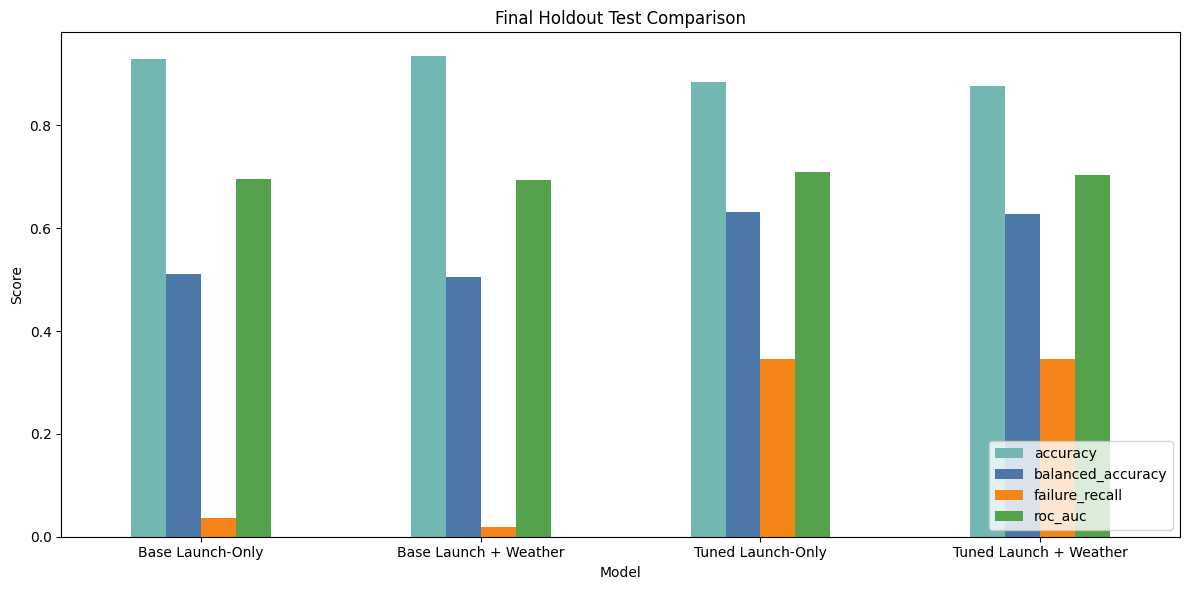

In [24]:
final_metric_plot_df = final_test_metrics.set_index("model")[
    ["accuracy", "balanced_accuracy", "failure_recall", "roc_auc"]
]

final_metric_plot_df.plot(
    kind="bar",
    figsize=(12, 6),
    color=["#72b7b2", "#4c78a8", "#f58518", "#54a24b"],
)
plt.title("Final Holdout Test Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

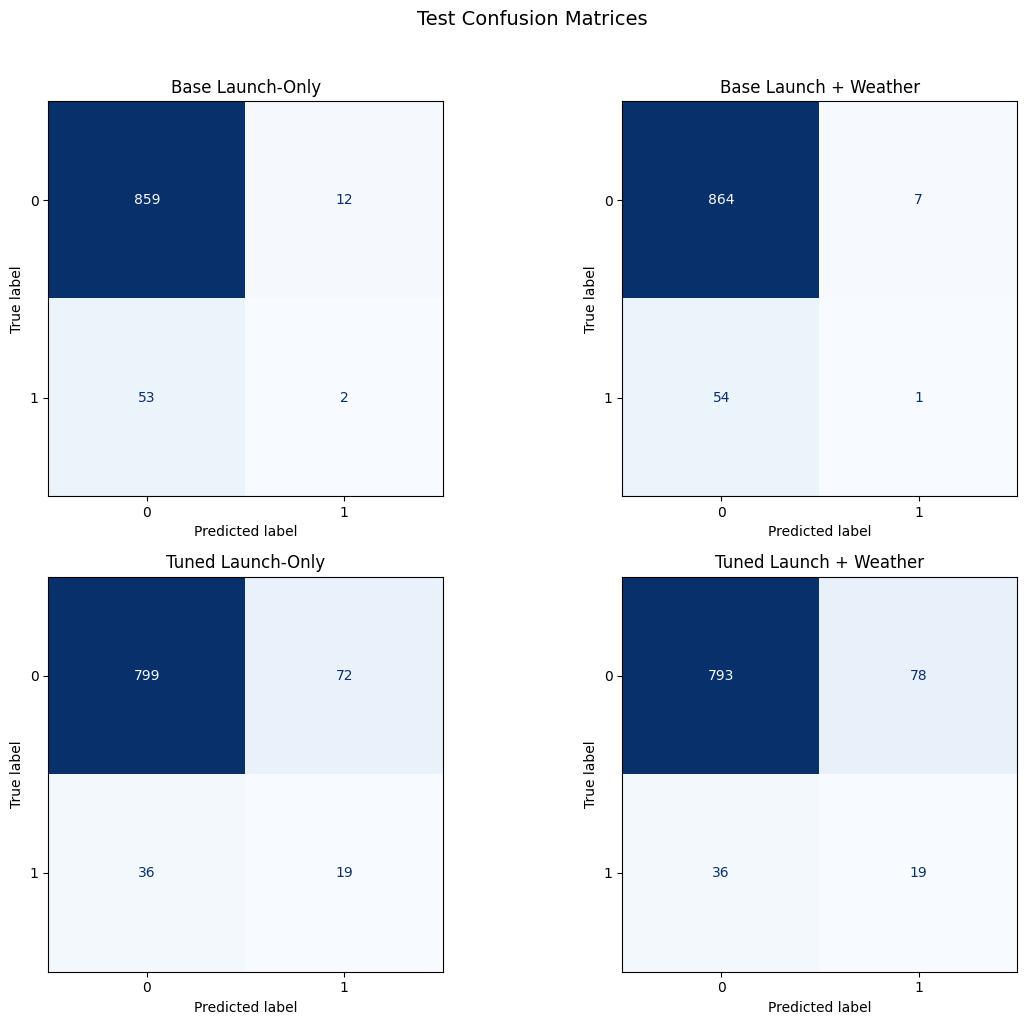

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

test_plot_inputs = [
    ("Base Launch-Only", final_models["Base Launch-Only"], split_data["launch_only"]["X_test"]),
    ("Base Launch + Weather", final_models["Base Launch + Weather"], split_data["launch_plus_weather"]["X_test"]),
    ("Tuned Launch-Only", final_models["Tuned Launch-Only"], split_data["launch_only"]["X_test"]),
    ("Tuned Launch + Weather", final_models["Tuned Launch + Weather"], split_data["launch_plus_weather"]["X_test"]),
]

for ax, (model_name, model, X_test_current) in zip(axes, test_plot_inputs):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        model.predict(X_test_current),
        ax=ax,
        cmap="Blues",
        colorbar=False,
    )
    ax.set_title(model_name)

plt.suptitle("Test Confusion Matrices", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

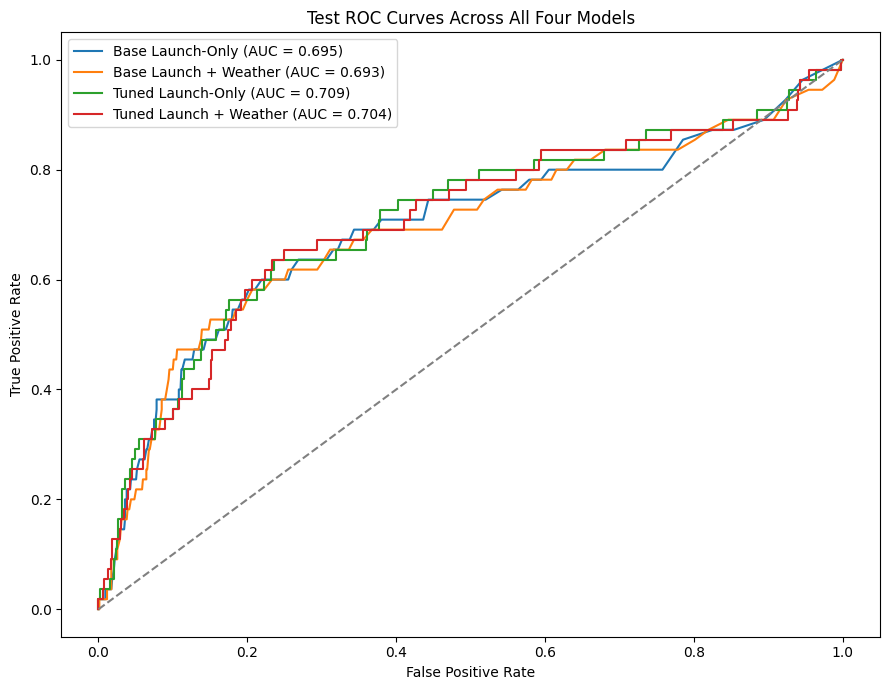

In [26]:
plt.figure(figsize=(9, 7))
for model_name, model, X_test_current in test_plot_inputs:
    y_score = model.predict_proba(X_test_current)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Test ROC Curves Across All Four Models")
plt.legend()
plt.tight_layout()
plt.show()

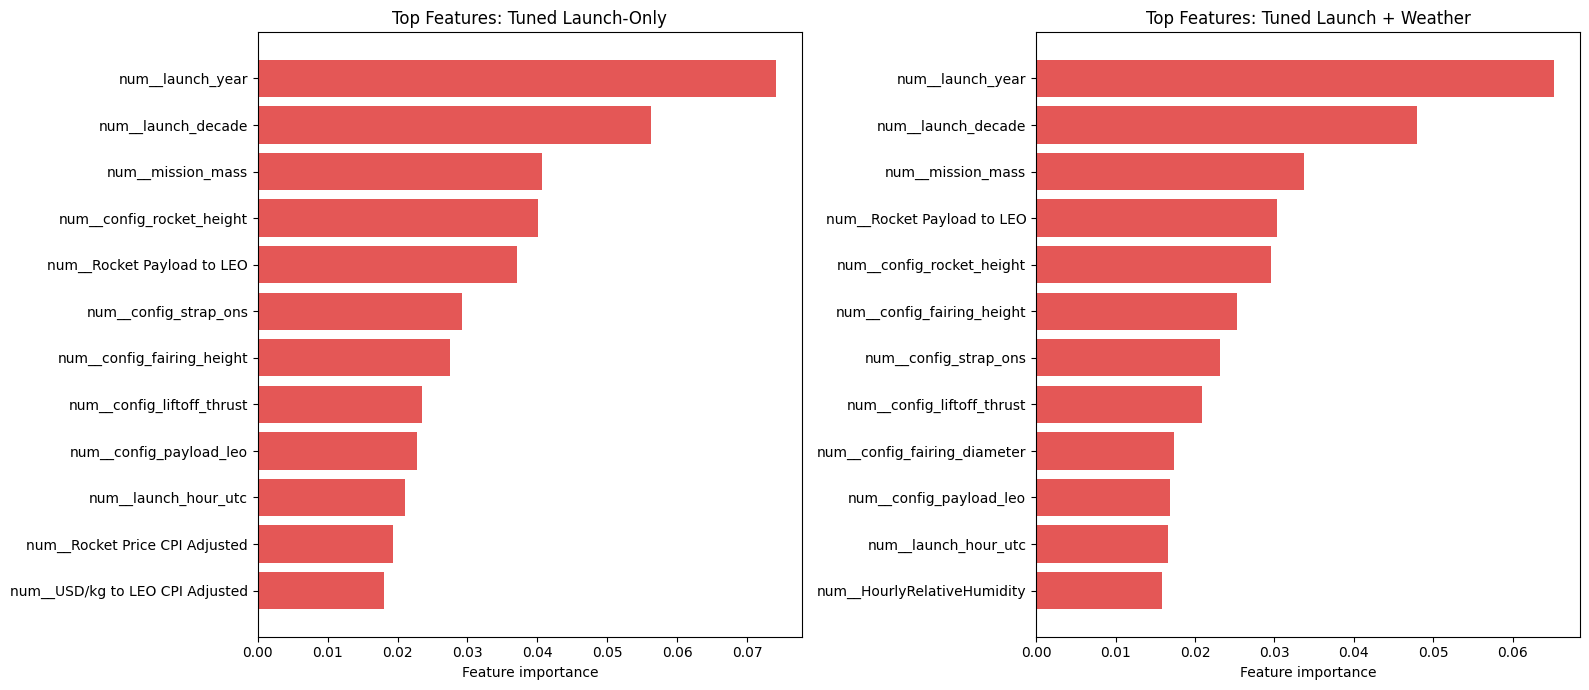

In [27]:
tuned_feature_importances = {
    "Tuned Launch-Only": get_feature_importance_frame(final_models["Tuned Launch-Only"], top_n=12),
    "Tuned Launch + Weather": get_feature_importance_frame(final_models["Tuned Launch + Weather"], top_n=12),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (model_name, importance_df) in zip(axes, tuned_feature_importances.items()):
    ax.barh(
        importance_df["feature"][::-1],
        importance_df["importance"][::-1],
        color="#e45756",
    )
    ax.set_title(f"Top Features: {model_name}")
    ax.set_xlabel("Feature importance")

plt.tight_layout()
plt.show()

In [28]:
print(interpretation_text(final_test_metrics, focus_split="test"))

Best ROC AUC on test: Tuned Launch-Only (0.7092).
Best balanced accuracy on test: Tuned Launch-Only (0.6314).
Weather lift in the base models: -0.0020 ROC AUC.
Weather lift in the tuned models: -0.0051 ROC AUC.


## Summary

By the end of the notebook, you should be able to answer four questions clearly:

1. How much signal is available from launch-specific features alone?
2. Does weather add useful predictive lift?
3. How much does hyperparameter tuning improve the model relative to the default forest?
4. Which model is strongest on the untouched test split once the comparison is made fairly?

In practice, the most important comparison is usually not raw accuracy. For this problem,
the strongest model should be the one that improves balanced accuracy, failure recall,
and ROC AUC without creating an unreasonable drop in failure precision.